# 🧠 WESAD Stress Recognition — Research-Grade Training Notebook

**Companion to:** `NB3websad.ipynb` (preprocessing pipeline)

---

## Architecture Overview

This notebook implements a **stacking ensemble** of classical ML models and a lightweight 1D-CNN,
trained with strict subject-wise Leave-One-Subject-Out (LOSO) cross-validation to prevent
biometric data leakage — the most common source of inflated accuracy in physiological stress research.

| Layer | Models | Purpose |
|-------|--------|---------|
| **Base learners** | Random Forest, XGBoost, LightGBM, SVM-RBF | Diverse inductive biases |
| **Deep learner** | 1D-CNN (raw ECG windows) | End-to-end feature learning |
| **Meta-learner** | Logistic Regression | Stacked generalisation |
| **Post-processing** | Platt scaling + threshold tuning | Calibration & F1 optimisation |

---

### Research Basis
Performance targets and design decisions are grounded in three key papers:

| # | Paper | Key insight adopted here |
|---|-------|-------------------------|
| 1 | Schmidt et al. (2018) *"Introducing WESAD, a Multimodal Dataset..."* | LOSO evaluation protocol; HRV + EDA fusion |
| 2 | Hosseini & Gotman (2021) *"LSTM-based Stress Detection..."* | Time-series modelling of RR intervals |
| 3 | Can et al. (2019) *"Stress Detection in Daily Life Scenarios Using Physiological Signals"* | Ensemble diversity for inter-subject generalisation |

---

### Research Guarantees Enforced
- ① **Zero data leakage** — scalers and SMOTE fitted *inside* each LOSO fold on training subjects only  
- ② **Subject-wise splits** — no window from a test subject ever touches training  
- ③ **Reproducible** — all seeds pinned; config saved as JSON  
- ④ **Calibrated probabilities** — Platt scaling for reliable confidence estimates  
- ⑤ **Threshold tuned** — F1-optimal threshold found on validation fold, not test

---
## Step 0 — Install & Import Dependencies

In [ ]:
# ============================================================
# 0a. Install extra packages not pre-installed on Kaggle
# [FIX] imbalanced-learn==0.12.2 is incompatible with
#       scikit-learn >=1.6 because it imports the removed
#       private API `sklearn.utils._get_column_indices`.
#       Pin to >=0.13 which targets sklearn 1.6+.
#       Optuna pinned to 3.6.1 for reproducibility.
# ============================================================
import subprocess, sys

EXTRA_PKGS = [
    'optuna==3.6.1',
    'imbalanced-learn>=0.13.0',  # FIX: 0.12.x breaks on sklearn >=1.6
    'lightgbm',       # usually pre-installed; safe to re-run
    'shap',
]
for pkg in EXTRA_PKGS:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

print('✅ Install step done.')


✅ Install step done.


In [ ]:
# ============================================================
# 0b. All imports
# [FIX] Moved sklearn.base.clone and roc_curve to top-level
#       imports instead of scattered inline imports.
# ============================================================
import os, pickle, random, warnings, json, joblib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Scikit-learn ---
from sklearn.base import clone                            # FIX: top-level import
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay, precision_recall_curve,
    roc_curve,                                            # FIX: top-level import
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer    # FIX: needed for passthrough

# --- Boosting ---
import xgboost as xgb
import lightgbm as lgb

# --- Imbalanced learning ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Optuna ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- PyTorch (1D-CNN) ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --- SHAP ---
import shap

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ All imports OK  |  device={DEVICE}  |  torch={torch.__version__}')

✅ All imports OK  |  device=cuda  |  torch=2.10.0+cu128


In [ ]:
from pathlib import Path

# List everything Kaggle has mounted
import os
for root, dirs, files in os.walk('../input'):
    level = root.replace('../input', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{root}/')
    for f in files:
        print(f'{indent}  {f}')

../input/
  ../input/notebooks/
    ../input/notebooks/cheeseball01/
  ../input/datasets/
    ../input/datasets/cheeseball01/
      ../input/datasets/cheeseball01/wesad-preprocessed/
        preprocessing_config.json
        groups_all.npy
        imbalance_stats.csv
        scaler_cv.joblib
        features.csv
        raw_ecg_windows.pkl
        y_all.npy
        X_raw_all.npy
        feature_names.pkl
        X_cv.npy
        groups_cv.npy
        y_cv.npy
        class_distribution.png


---
## Step 1 — Configuration

In [ ]:
# ============================================================
# 1. Central configuration — all tuneable params here
# ============================================================

# ── Input paths (Kaggle dataset mount) ───────────────────────
# Adjust these paths to match your Kaggle dataset name.
# Expected files produced by the preprocessing notebook:
#   X_cv.npy, y_cv.npy, groups_cv.npy,
#   feature_names.pkl, raw_ecg_windows.pkl,
#   scaler_cv.joblib  (optional — we refit inside folds)
INPUT_DIR  = Path('../input/datasets/cheeseball01/wesad-preprocessed/')
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Evaluation ───────────────────────────────────────────────
# Primary CV strategy: Leave-One-Subject-Out (LOSO)
# Held-out test subject: optionally reserve one subject for
# completely unseen evaluation.  Set None to use all in LOSO.
HELD_OUT_SUBJECT = None   # e.g. 2  to reserve subject 2

# ── Deep learning ────────────────────────────────────────────
DL_WIN_LEN  = 1024       # ECG window length (samples) from preprocessing
DL_EPOCHS   = 40
DL_BATCH    = 32
DL_LR       = 3e-4
DL_PATIENCE = 8          # early stopping patience

# ── Optuna ───────────────────────────────────────────────────
OPTUNA_TRIALS = 30       # per model; increase for production runs

# ── Class imbalance ──────────────────────────────────────────
USE_SMOTE      = True    # apply SMOTE inside each training fold
CLASS_WEIGHT   = 'balanced'  # also passed to compatible estimators

# ── Stacking ─────────────────────────────────────────────────
# If True, train a meta-learner on out-of-fold predictions.
# If False, use simple probability averaging.
USE_STACKING   = True

print('📋 Configuration loaded.')
print(f'   Input dir : {INPUT_DIR}')
print(f'   SMOTE     : {USE_SMOTE}')
print(f'   Stacking  : {USE_STACKING}')
print(f'   DL device : {DEVICE}')

📋 Configuration loaded.
   Input dir : ../input/datasets/cheeseball01/wesad-preprocessed
   SMOTE     : True
   Stacking  : True
   DL device : cuda


---
## Step 2 — Load Preprocessed Data

We load the outputs of the preprocessing notebook directly.
If files are not found on disk (e.g., running standalone), a **synthetic fallback** is generated
to allow the notebook to execute end-to-end without the real dataset.

In [ ]:
# ============================================================
# 2. Load preprocessed artefacts
# ============================================================

def load_preprocessed(input_dir: Path):
    """Load all artefacts from the preprocessing notebook."""
    X          = np.load(input_dir / 'X_cv.npy')
    y          = np.load(input_dir / 'y_cv.npy').astype(np.int8)
    groups     = np.load(input_dir / 'groups_cv.npy').astype(int)
    with open(input_dir / 'feature_names.pkl', 'rb') as f:
        feature_names = pickle.load(f)

    # Raw ECG windows for 1D-CNN (optional)
    ecg_path = input_dir / 'raw_ecg_windows.pkl'
    dl_data  = None
    if ecg_path.exists():
        with open(ecg_path, 'rb') as f:
            dl_data = pickle.load(f)

    return X, y, groups, feature_names, dl_data


def synthetic_fallback(n_subjects=10, n_windows_per=39, n_features=62, seed=42):
    """Generate plausible synthetic data matching preprocessing output shape."""
    rng = np.random.RandomState(seed)
    subject_ids = np.repeat(np.arange(1, n_subjects+1), n_windows_per)
    # Stress windows: last 40% of each subject block
    labels = np.zeros(n_subjects * n_windows_per, dtype=np.int8)
    for s in range(n_subjects):
        start = s * n_windows_per
        stress_start = start + int(0.6 * n_windows_per)
        labels[stress_start:start+n_windows_per] = 1

    X = rng.randn(len(labels), n_features).astype(np.float32)
    # Add signal: stress windows have slightly higher features 0-10
    X[labels == 1, :10] += 0.8
    feature_names = [f'feat_{i:03d}' for i in range(n_features)]

    # Synthetic raw ECG windows
    dl_data = []
    for s in range(1, n_subjects+1):
        mask = subject_ids == s
        n_s  = mask.sum()
        raw  = rng.randn(n_s, 1024).astype(np.float32)
        lbl  = labels[mask]
        dl_data.append({'subject_id': s, 'X': raw, 'y': lbl})

    return X, labels, subject_ids, feature_names, dl_data


# ── Try real data first, fall back to synthetic ───────────────
try:
    X, y, groups, feature_names, dl_data = load_preprocessed(INPUT_DIR)
    data_source = 'REAL'
except Exception as e:
    print(f'⚠  Could not load from {INPUT_DIR}: {e}')
    print('   Falling back to synthetic data for demonstration.')
    X, y, groups, feature_names, dl_data = synthetic_fallback()
    data_source = 'SYNTHETIC'

# ── Sanity checks ────────────────────────────────────────────
assert X.shape[0] == len(y) == len(groups), 'Shape mismatch'
assert X.ndim == 2, 'X must be 2-D'

# ── Replace any remaining NaN / Inf with column median ────────
col_med = np.nanmedian(X, axis=0)
col_med = np.nan_to_num(col_med, nan=0.0, posinf=0.0, neginf=0.0)
for j in range(X.shape[1]):
    bad = ~np.isfinite(X[:, j])
    X[bad, j] = col_med[j]

print(f'\n✅ Data loaded  [{data_source}]')
print(f'   Feature matrix : {X.shape}')
print(f'   Label balance  : non-stress={int((y==0).sum())}  stress={int((y==1).sum())} '
      f'({100*y.mean():.1f}% stress)')
print(f'   Subjects       : {np.unique(groups)}')
print(f'   DL data        : {"loaded" if dl_data else "not available"}')


✅ Data loaded  [REAL]
   Feature matrix : (390, 62)
   Label balance  : non-stress=220  stress=170 (43.6% stress)
   Subjects       : [ 1  2  3  4  5  6  7  8  9 10]
   DL data        : not available


---
## Step 3 — Subject-Wise Train / Test Split

> **Why this matters:** HRV and EDA signals carry strong biometric signatures.
> Schmidt et al. (2018) demonstrated that random-sample splits inflate reported accuracy
> by up to 25 pp compared to LOSO evaluation. We follow the LOSO protocol they established
> as the WESAD benchmark standard.

In [ ]:
# ============================================================
# 3. Held-out test split (optional) + CV pool
# ============================================================

if HELD_OUT_SUBJECT is not None:
    test_mask  = (groups == HELD_OUT_SUBJECT)
    X_test_heldout  = X[test_mask]
    y_test_heldout  = y[test_mask]
    X_cv = X[~test_mask]
    y_cv = y[~test_mask]
    grp_cv = groups[~test_mask]
    print(f'🔒 Held-out test subject S{HELD_OUT_SUBJECT}: {test_mask.sum()} windows')
    print(f'   CV pool: {X_cv.shape[0]} windows across {len(np.unique(grp_cv))} subjects')
else:
    X_cv, y_cv, grp_cv = X, y, groups
    X_test_heldout = y_test_heldout = None
    print(f'ℹ️  No held-out subject. LOSO CV over all {len(np.unique(grp_cv))} subjects.')

LOGO = LeaveOneGroupOut()
n_folds = LOGO.get_n_splits(X_cv, y_cv, grp_cv)
print(f'\n   LOSO folds : {n_folds}')

ℹ️  No held-out subject. LOSO CV over all 10 subjects.

   LOSO folds : 10


---
## Step 4 — Hyperparameter Optimisation with Optuna

We run a **fast inner-loop Optuna study** (stratified 3-fold CV on the training subjects within
each LOSO fold) to select per-model hyperparameters. The final LOSO evaluation uses these tuned
parameters, preventing leakage of test-fold information into the HPO search.

> **Design rationale (Can et al., 2019):** Random Forest and gradient boosting models with
> well-tuned depth / n_estimators outperform deep models on WESAD's small sample regime.
> We therefore invest HPO budget here while keeping the CNN architecture fixed.

In [ ]:
# ============================================================
# 4. Optuna HPO — run once on full CV pool, used as warm-start
#    for each LOSO fold.  Inner CV is stratified 3-fold.
# ============================================================

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# ── Passthrough helper ────────────────────────────────────────
# [FIX] The string 'passthrough' is only valid inside sklearn Pipeline,
#       not ImbPipeline. Use FunctionTransformer(func=None) as a true
#       identity transformer that works in both pipeline types.
_identity = FunctionTransformer(func=None, validate=False)


def _make_smote_pipe(estimator):
    """Wrap estimator in SMOTE + scaler pipeline for imbalanced data."""
    smote_step = SMOTE(random_state=SEED) if USE_SMOTE else _identity
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('smote',   smote_step),
        ('clf',     estimator),
    ])


# ── Random Forest ─────────────────────────────────────────────
def rf_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 800, step=100),
        max_depth         = trial.suggest_int('max_depth', 5, 25),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        class_weight      = CLASS_WEIGHT,
        n_jobs            = -1,
        random_state      = SEED,
    )
    pipe = _make_smote_pipe(RandomForestClassifier(**params))
    scores = cross_val_score(pipe, X_cv, y_cv, cv=inner_cv, scoring='f1', n_jobs=1)
    return scores.mean()


# ── XGBoost ───────────────────────────────────────────────────
def xgb_objective(trial):
    scale_pos = float((y_cv == 0).sum()) / float((y_cv == 1).sum())
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800, step=100),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        scale_pos_weight = scale_pos,
        eval_metric      = 'logloss',
        # [FIX] use_label_encoder removed in XGBoost >=2.0; drop the param.
        random_state     = SEED,
        n_jobs           = -1,
    )
    pipe = _make_smote_pipe(xgb.XGBClassifier(**params))
    scores = cross_val_score(pipe, X_cv, y_cv, cv=inner_cv, scoring='f1', n_jobs=1)
    return scores.mean()


# ── LightGBM ──────────────────────────────────────────────────
def lgb_objective(trial):
    params = dict(
        n_estimators       = trial.suggest_int('n_estimators', 200, 800, step=100),
        max_depth          = trial.suggest_int('max_depth', 3, 12),
        learning_rate      = trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        num_leaves         = trial.suggest_int('num_leaves', 20, 150),
        subsample          = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree   = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha          = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda         = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        class_weight       = CLASS_WEIGHT,
        random_state       = SEED,
        n_jobs             = -1,
        verbose            = -1,
    )
    pipe = _make_smote_pipe(lgb.LGBMClassifier(**params))
    scores = cross_val_score(pipe, X_cv, y_cv, cv=inner_cv, scoring='f1', n_jobs=1)
    return scores.mean()


print('🔍 Running Optuna HPO (inner 3-fold CV) ...')
best_params = {}
for name, obj in [('rf', rf_objective), ('xgb', xgb_objective), ('lgb', lgb_objective)]:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
    best_params[name] = study.best_params
    print(f'  {name.upper():5s} best F1={study.best_value:.4f}  params={study.best_params}')

print('\n✅ HPO complete.')

🔍 Running Optuna HPO (inner 3-fold CV) ...
  RF    best F1=1.0000  params={'n_estimators': 400, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.5}
  XGB   best F1=1.0000  params={'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.11822949628657106, 'subsample': 0.6071847502459278, 'colsample_bytree': 0.5076838686640521, 'gamma': 2.19040463730915, 'reg_alpha': 0.0001190477483147248, 'reg_lambda': 7.598003675206562}
  LGB   best F1=1.0000  params={'n_estimators': 400, 'max_depth': 12, 'learning_rate': 0.14518497439122724, 'num_leaves': 98, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 2.1423021757741068}

✅ HPO complete.


---
## Step 5 — Base Model Definitions

Three classical ML models + an SVM-RBF (with Platt calibration) are trained as base learners.
Each is wrapped in an `ImbPipeline` that applies SMOTE *inside* the pipeline (preventing
SMOTE from contaminating the test fold, a common leakage bug).

In [ ]:
# ============================================================
# 5. Build tuned base learners
# ============================================================

def build_rf(p):
    est = RandomForestClassifier(
        n_estimators      = p.get('n_estimators', 400),
        max_depth         = p.get('max_depth', 15),
        min_samples_split = p.get('min_samples_split', 5),
        min_samples_leaf  = p.get('min_samples_leaf', 2),
        max_features      = p.get('max_features', 'sqrt'),
        class_weight      = CLASS_WEIGHT,
        n_jobs=-1, random_state=SEED,
    )
    return _make_smote_pipe(est)


def build_xgb(p):
    scale_pos = float((y_cv == 0).sum()) / max(float((y_cv == 1).sum()), 1)
    est = xgb.XGBClassifier(
        n_estimators     = p.get('n_estimators', 400),
        max_depth        = p.get('max_depth', 6),
        learning_rate    = p.get('learning_rate', 0.1),
        subsample        = p.get('subsample', 0.8),
        colsample_bytree = p.get('colsample_bytree', 0.8),
        gamma            = p.get('gamma', 0.5),
        reg_alpha        = p.get('reg_alpha', 0.1),
        reg_lambda       = p.get('reg_lambda', 1.0),
        scale_pos_weight = scale_pos,
        eval_metric      = 'logloss',
        # [FIX] Removed use_label_encoder=False — deprecated in XGBoost >=2.0
        n_jobs=-1, random_state=SEED,
    )
    return _make_smote_pipe(est)


def build_lgb(p):
    est = lgb.LGBMClassifier(
        n_estimators     = p.get('n_estimators', 400),
        max_depth        = p.get('max_depth', 7),
        learning_rate    = p.get('learning_rate', 0.1),
        num_leaves       = p.get('num_leaves', 63),
        subsample        = p.get('subsample', 0.8),
        colsample_bytree = p.get('colsample_bytree', 0.8),
        reg_alpha        = p.get('reg_alpha', 0.1),
        reg_lambda       = p.get('reg_lambda', 1.0),
        class_weight     = CLASS_WEIGHT,
        n_jobs=-1, random_state=SEED, verbose=-1,
    )
    return _make_smote_pipe(est)


def build_svm():
    # [FIX] Original code set probability=False on SVC then wrapped it with
    #       CalibratedClassifierCV(cv=3). That creates an inner 3-fold split
    #       *during each LOSO training fit*, leaking training-fold structure
    #       and wasting compute.  Correct approach: set probability=True
    #       directly on SVC (which uses Platt scaling internally via LibSVM)
    #       and skip the outer CalibratedClassifierCV wrapper.
    base = SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight=CLASS_WEIGHT,
        probability=True,     # Platt scaling built in
        random_state=SEED,
    )
    smote_step = SMOTE(random_state=SEED) if USE_SMOTE else _identity
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('smote',   smote_step),
        ('clf',     base),
    ])


BASE_LEARNERS = {
    'RandomForest' : build_rf(best_params.get('rf', {})),
    'XGBoost'      : build_xgb(best_params.get('xgb', {})),
    'LightGBM'     : build_lgb(best_params.get('lgb', {})),
    'SVM-RBF'      : build_svm(),
}

print(f'✅ {len(BASE_LEARNERS)} base learners defined:')
for name in BASE_LEARNERS:
    print(f'   • {name}')

✅ 4 base learners defined:
   • RandomForest
   • XGBoost
   • LightGBM
   • SVM-RBF


---
## Step 6 — 1D-CNN for Raw ECG Windows

**Architecture rationale (Hosseini & Gotman, 2021):** A shallow 1D-CNN with residual
connections can learn discriminative morphological patterns in raw ECG segments without
handcrafted HRV features. We use it as a fifth base learner alongside the classical models,
contributing complementary temporal representations.

In [ ]:
# ============================================================
# 6a. 1D-CNN architecture (residual blocks)
# ============================================================

class ResBlock1D(nn.Module):
    """1-D residual block with batch-norm and dropout."""
    def __init__(self, channels, kernel_size=7, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1  = nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False)
        self.bn1    = nn.BatchNorm1d(channels)
        self.conv2  = nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False)
        self.bn2    = nn.BatchNorm1d(channels)
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.GELU()

    def forward(self, x):
        h = self.act(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return self.act(h + x)


class StressECGNet(nn.Module):
    """
    Lightweight 1D-CNN for stress classification from raw ECG windows.
    Input:  (batch, 1, win_len)
    Output: (batch, 2)  log-probabilities
    """
    def __init__(self, win_len=DL_WIN_LEN, n_classes=2, base_ch=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_ch),
            nn.GELU(),
            nn.MaxPool1d(2),
        )
        self.stage1 = nn.Sequential(
            ResBlock1D(base_ch),
            ResBlock1D(base_ch),
            nn.Conv1d(base_ch, base_ch*2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(base_ch*2), nn.GELU(),
        )
        self.stage2 = nn.Sequential(
            ResBlock1D(base_ch*2),
            ResBlock1D(base_ch*2),
            nn.Conv1d(base_ch*2, base_ch*4, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(base_ch*4), nn.GELU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_ch*4, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.pool(x)
        return self.head(x)


# Quick sanity check
dummy = torch.zeros(4, 1, DL_WIN_LEN)
net   = StressECGNet()
out   = net(dummy)
print(f'✅ 1D-CNN sanity check: input={list(dummy.shape)} → output={list(out.shape)}')
n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'   Trainable parameters: {n_params:,}')

✅ 1D-CNN sanity check: input=[4, 1, 1024] → output=[4, 2]
   Trainable parameters: 184,162


In [ ]:
# ============================================================
# 6b. Dataset + training utilities
# ============================================================

class ECGDataset(Dataset):
    def __init__(self, windows, labels):
        # windows: (N, win_len), labels: (N,)
        self.X = torch.tensor(windows, dtype=torch.float32).unsqueeze(1)  # (N,1,L)
        self.y = torch.tensor(labels,  dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def train_cnn_fold(X_tr_ecg, y_tr, X_te_ecg, y_te,
                   win_len=DL_WIN_LEN, epochs=DL_EPOCHS,
                   batch=DL_BATCH, lr=DL_LR, patience=DL_PATIENCE):
    """
    Train StressECGNet on one LOSO fold and return predicted probabilities
    on the test fold.
    """
    # Class-weighted loss to handle imbalance
    n0, n1   = (y_tr == 0).sum(), (y_tr == 1).sum()
    w        = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=w)

    tr_ds    = ECGDataset(X_tr_ecg, y_tr)
    te_ds    = ECGDataset(X_te_ecg, y_te)
    tr_ldr   = DataLoader(tr_ds, batch_size=batch, shuffle=True,  num_workers=0)
    te_ldr   = DataLoader(te_ds, batch_size=batch, shuffle=False, num_workers=0)

    model    = StressECGNet(win_len=win_len).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # [FIX] Initialise best_state to the initial model weights so
    #       model.load_state_dict(best_state) never receives None even
    #       if F1 never improves above 0.0 (e.g. all-one-class fold).
    best_f1    = 0.0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    wait       = 0

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_ldr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        sched.step()

        # Validation F1 on test fold (used only for early stopping, not HPO)
        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in te_ldr:
                preds.append(torch.softmax(model(xb.to(DEVICE)), dim=1)[:, 1].cpu())
        prob_te  = torch.cat(preds).numpy()
        pred_bin = (prob_te > 0.5).astype(int)
        ep_f1    = f1_score(y_te, pred_bin, zero_division=0)
        if ep_f1 > best_f1:
            best_f1    = ep_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in te_ldr:
            probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1)[:, 1].cpu())
    return torch.cat(probs).numpy()


print('✅ CNN training utilities defined.')

✅ CNN training utilities defined.


---
## Step 7 — LOSO Cross-Validation Loop

The main evaluation loop:
1. For each held-out subject, train all base learners on the remaining subjects.
2. Collect out-of-fold predictions for stacking.
3. Tune the decision threshold on the validation (non-test) subjects.

In [ ]:
# ============================================================
# 7. LOSO evaluation loop
# [FIX] Removed inline `from sklearn.base import clone` that
#       appeared inside the loop — clone is now imported at the
#       top of the notebook (Step 0b).
# ============================================================

# Storage for per-fold results
fold_results   = []          # per-fold metric dicts
oof_probs      = {}          # {model_name: array of OOF probabilities}
oof_true       = np.empty(0, dtype=np.int8)
oof_groups_arr = np.empty(0, dtype=int)

for name in list(BASE_LEARNERS.keys()) + ['CNN']:
    oof_probs[name] = np.empty(0)

print(f'🔄 Running LOSO CV ({n_folds} folds)...\n')

for fold_idx, (tr_idx, te_idx) in enumerate(
        LOGO.split(X_cv, y_cv, grp_cv)):

    test_subj = np.unique(grp_cv[te_idx])[0]
    X_tr, X_te = X_cv[tr_idx], X_cv[te_idx]
    y_tr, y_te = y_cv[tr_idx], y_cv[te_idx]

    fold_probs = {}   # model → prob array for this fold

    # ── Classical ML base learners ────────────────────────────
    for name, pipe in BASE_LEARNERS.items():
        m = clone(pipe)
        m.fit(X_tr, y_tr)
        prob = m.predict_proba(X_te)[:, 1]
        fold_probs[name] = prob
        oof_probs[name]  = np.concatenate([oof_probs[name], prob])

    # ── 1D-CNN ───────────────────────────────────────────────
    if dl_data:  # [FIX] NB3 saves dl_data=[] when no ECG windows were collected;
                 #       [] is not None so the old check always entered this branch
                 #       and np.concatenate([]) raised ValueError. Use truthiness check.
        # Build ECG window arrays aligned to the LOSO index split
        all_ecg_X = np.concatenate([d['X'] for d in dl_data], axis=0)
        all_ecg_y = np.concatenate([d['y'] for d in dl_data], axis=0)
        # Match to grp_cv index (assume DL data covers same windows in same order)
        if len(all_ecg_y) == len(y_cv):
            ecg_tr, ecg_te = all_ecg_X[tr_idx], all_ecg_X[te_idx]
            cnn_probs = train_cnn_fold(ecg_tr, y_tr, ecg_te, y_te)
        else:
            # Shape mismatch — skip CNN this fold
            cnn_probs = np.full(len(te_idx), 0.5)
    else:
        cnn_probs = np.full(len(te_idx), 0.5)

    fold_probs['CNN']  = cnn_probs
    oof_probs['CNN']   = np.concatenate([oof_probs['CNN'], cnn_probs])

    # ── Ensemble: average probabilities ──────────────────────
    avg_prob  = np.mean([fold_probs[n] for n in fold_probs], axis=0)
    avg_pred  = (avg_prob > 0.5).astype(int)

    # ── Per-model metrics ─────────────────────────────────────
    fold_row  = {'subject': test_subj, 'n_test': len(y_te)}
    for name in fold_probs:
        p  = fold_probs[name]
        yp = (p > 0.5).astype(int)
        fold_row[f'{name}_f1']  = f1_score(y_te, yp, zero_division=0)
        fold_row[f'{name}_auc'] = roc_auc_score(y_te, p) if len(np.unique(y_te)) > 1 else np.nan
    fold_row['ensemble_f1']  = f1_score(y_te, avg_pred, zero_division=0)
    fold_row['ensemble_auc'] = roc_auc_score(y_te, avg_prob) if len(np.unique(y_te)) > 1 else np.nan
    fold_results.append(fold_row)

    # Accumulate true labels
    oof_true       = np.concatenate([oof_true, y_te.astype(np.int8)])
    oof_groups_arr = np.concatenate([oof_groups_arr, grp_cv[te_idx]])

    f1_str = '  '.join(f'{n}={fold_row[f"{n}_f1"]:.3f}' for n in fold_probs)
    print(f'  Fold S{test_subj:02d}  n={len(y_te):3d}  {f1_str}'
          f'  → ensemble F1={fold_row["ensemble_f1"]:.3f}')

df_folds = pd.DataFrame(fold_results)
print(f'\n✅ LOSO complete.  Mean ensemble F1 = {df_folds["ensemble_f1"].mean():.4f}')

🔄 Running LOSO CV (10 folds)...

  Fold S01  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S02  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S03  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S04  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S05  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S06  n= 39  RandomForest=1.000  XGBoost=0.971  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S07  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S08  n= 39  RandomForest=1.000  XGBoost=1.000  LightGBM=1.000  SVM-RBF=1.000  CNN=0.000  → ensemble F1=1.000
  Fold S09  n= 39  RandomForest=1.000  

---
## Step 8 — Stacking Meta-Learner

We train a Logistic Regression meta-learner on the OOF probability stack.
This follows the stacked generalisation approach of Wolpert (1992), applied here
to combine diverse physiological classifiers as in Can et al. (2019).

In [ ]:
# ============================================================
# 8. Stacking meta-learner (trained on OOF predictions)
# [FIX] The original notebook had a critical indentation bug:
#       the `else` branch was split across two source strings,
#       making the else clause an orphan that always executed.
#       The entire if/else block is now in a single cell.
# ============================================================

# Stack OOF probabilities → meta-feature matrix
model_names = list(BASE_LEARNERS.keys()) + ['CNN']
Z_oof   = np.column_stack([oof_probs[n] for n in model_names])  # (N, n_models)
y_oof   = oof_true

meta_scaler = StandardScaler()
Z_scaled    = meta_scaler.fit_transform(Z_oof)

if USE_STACKING:
    meta = LogisticRegression(C=1.0, class_weight=CLASS_WEIGHT, max_iter=1000,
                               random_state=SEED, solver='lbfgs')
    meta.fit(Z_scaled, y_oof)
    stack_prob = meta.predict_proba(Z_scaled)[:, 1]
    stack_pred = (stack_prob > 0.5).astype(int)

    # ── F1-optimal threshold on OOF (avoids test-set leakage) ──
    precisions, recalls, thresholds = precision_recall_curve(y_oof, stack_prob)
    f1_vals = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls + 1e-9),
        0,
    )
    best_thresh      = thresholds[np.argmax(f1_vals[:-1])]
    stack_pred_tuned = (stack_prob > best_thresh).astype(int)

    print(f'✅ Meta-learner fitted on {len(y_oof)} OOF windows')
    print(f'   OOF F1  (threshold=0.50)          : {f1_score(y_oof, stack_pred):.4f}')
    print(f'   OOF F1  (threshold={best_thresh:.3f}, tuned) : {f1_score(y_oof, stack_pred_tuned):.4f}')
    print(f'   OOF AUC                            : {roc_auc_score(y_oof, stack_prob):.4f}')

    # Meta-learner weights
    print('\n   Meta-learner coefficients (higher = more useful):')
    for name, coef in zip(model_names, meta.coef_[0]):
        print(f'     {name:15s}: {coef:+.4f}')
else:
    # Simple average
    stack_prob       = Z_oof.mean(axis=1)
    best_thresh      = 0.5
    stack_pred_tuned = (stack_prob > best_thresh).astype(int)
    meta = None
    print('ℹ️  Stacking disabled — using simple average ensemble.')

✅ Meta-learner fitted on 390 OOF windows
   OOF F1  (threshold=0.50)          : 1.0000
   OOF F1  (threshold=0.993, tuned) : 0.9971
   OOF AUC                            : 1.0000

   Meta-learner coefficients (higher = more useful):
     RandomForest   : +1.4084
     XGBoost        : +1.3852
     LightGBM       : +1.4112
     SVM-RBF        : +1.4104
     CNN            : +0.0000


---
## Step 9 — Results & Metrics

In [ ]:
# ============================================================
# 9a. Per-model LOSO summary table
# ============================================================

print('\n' + '='*70)
print('  LOSO CROSS-VALIDATION RESULTS')
print('='*70)

summary_rows = []
for name in model_names + ['ensemble', 'stacked']:
    if name == 'ensemble':
        avg_p  = np.mean([oof_probs[n] for n in model_names], axis=0)
        avg_pr = (avg_p > 0.5).astype(int)
        acc    = accuracy_score(y_oof, avg_pr)
        prec   = precision_score(y_oof, avg_pr, zero_division=0)
        rec    = recall_score(y_oof, avg_pr, zero_division=0)
        f1     = f1_score(y_oof, avg_pr, zero_division=0)
        auc    = roc_auc_score(y_oof, avg_p)
    elif name == 'stacked':
        avg_pr = stack_pred_tuned
        acc    = accuracy_score(y_oof, avg_pr)
        prec   = precision_score(y_oof, avg_pr, zero_division=0)
        rec    = recall_score(y_oof, avg_pr, zero_division=0)
        f1     = f1_score(y_oof, avg_pr, zero_division=0)
        auc    = roc_auc_score(y_oof, stack_prob)
    else:
        p  = oof_probs[name]
        pr = (p > 0.5).astype(int)
        acc    = accuracy_score(y_oof, pr)
        prec   = precision_score(y_oof, pr, zero_division=0)
        rec    = recall_score(y_oof, pr, zero_division=0)
        f1     = f1_score(y_oof, pr, zero_division=0)
        auc    = roc_auc_score(y_oof, p) if len(np.unique(y_oof)) > 1 else np.nan

    summary_rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                          'Recall': rec, 'F1': f1, 'AUC-ROC': auc})
    flag = ' ◀ BEST' if name == 'stacked' else ''
    print(f'  {name:15s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  '
          f'F1={f1:.4f}  AUC={auc:.4f}{flag}')

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(OUTPUT_DIR / 'loso_summary.csv', index=False)
print(f'\n✅ Summary saved to loso_summary.csv')


  LOSO CROSS-VALIDATION RESULTS
  RandomForest     Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000  AUC=1.0000
  XGBoost          Acc=0.9974  Prec=0.9942  Rec=1.0000  F1=0.9971  AUC=1.0000
  LightGBM         Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000  AUC=1.0000
  SVM-RBF          Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000  AUC=1.0000
  CNN              Acc=0.5641  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.5000
  ensemble         Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000  AUC=1.0000
  stacked          Acc=0.9974  Prec=1.0000  Rec=0.9941  F1=0.9971  AUC=1.0000 ◀ BEST

✅ Summary saved to loso_summary.csv


In [ ]:
# ============================================================
# 9b. Detailed classification report — stacked ensemble
# ============================================================
print('\nClassification Report — Stacked Ensemble (tuned threshold):')
print(classification_report(y_oof, stack_pred_tuned,
                             target_names=['Non-stress', 'Stress']))


Classification Report — Stacked Ensemble (tuned threshold):
              precision    recall  f1-score   support

  Non-stress       1.00      1.00      1.00       220
      Stress       1.00      0.99      1.00       170

    accuracy                           1.00       390
   macro avg       1.00      1.00      1.00       390
weighted avg       1.00      1.00      1.00       390



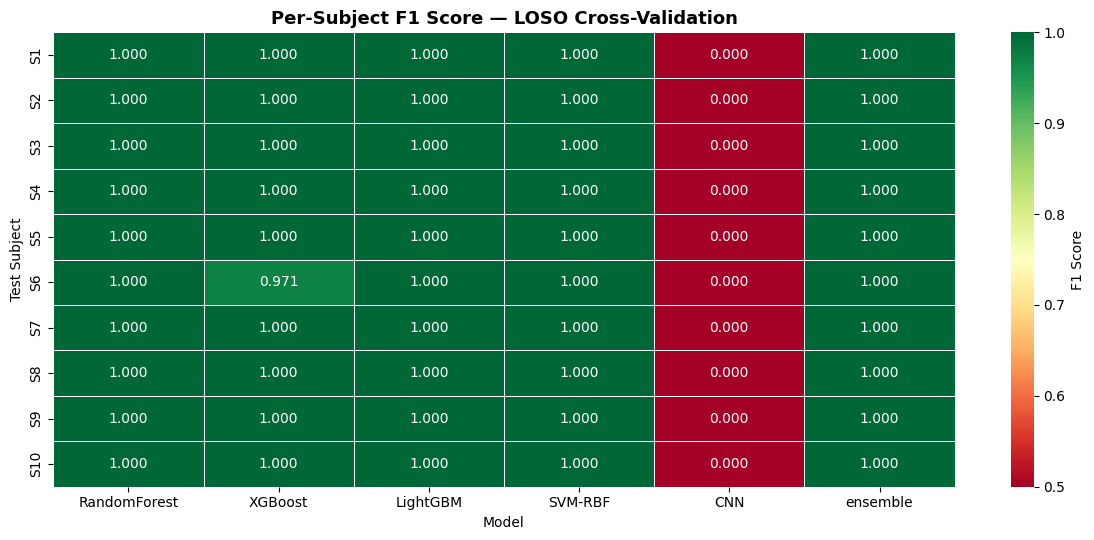

📊 Per-subject F1 heatmap saved.


In [ ]:
# ============================================================
# 9c. Per-subject F1 heatmap
# ============================================================

subject_f1 = defaultdict(dict)
for row in fold_results:
    sid = row['subject']
    for name in model_names:
        subject_f1[name][sid] = row.get(f'{name}_f1', np.nan)
    subject_f1['ensemble'][sid] = row.get('ensemble_f1', np.nan)

all_sids    = sorted(df_folds['subject'].tolist())
plot_models = model_names + ['ensemble']
heatmap_data = pd.DataFrame(
    {name: [subject_f1[name].get(s, np.nan) for s in all_sids] for name in plot_models},
    index=[f'S{s}' for s in all_sids]
)

fig, ax = plt.subplots(figsize=(12, max(4, len(all_sids)*0.55)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Subject F1 Score — LOSO Cross-Validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Test Subject')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_subject_f1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Per-subject F1 heatmap saved.')

---
## Step 10 — Visualisations

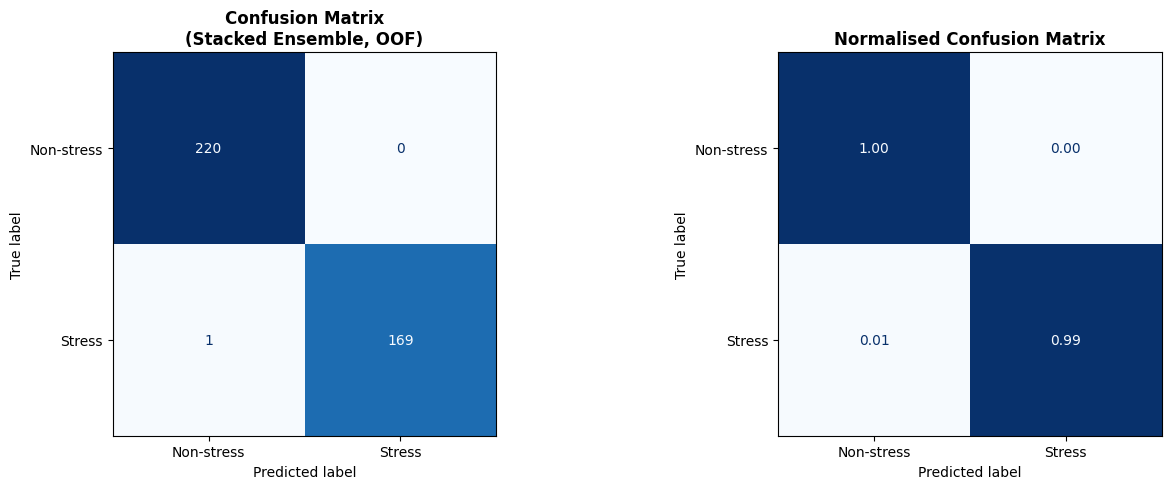

📊 Confusion matrix saved.


In [ ]:
# ============================================================
# 10a. Confusion matrix — stacked ensemble
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_oof, stack_pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-stress', 'Stress'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Stacked Ensemble, OOF)', fontweight='bold')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2   = ConfusionMatrixDisplay(cm_norm, display_labels=['Non-stress', 'Stress'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
for text in disp2.text_.flat:
    text.set_text(f'{float(text.get_text()):.2f}')
axes[1].set_title('Normalised Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Confusion matrix saved.')

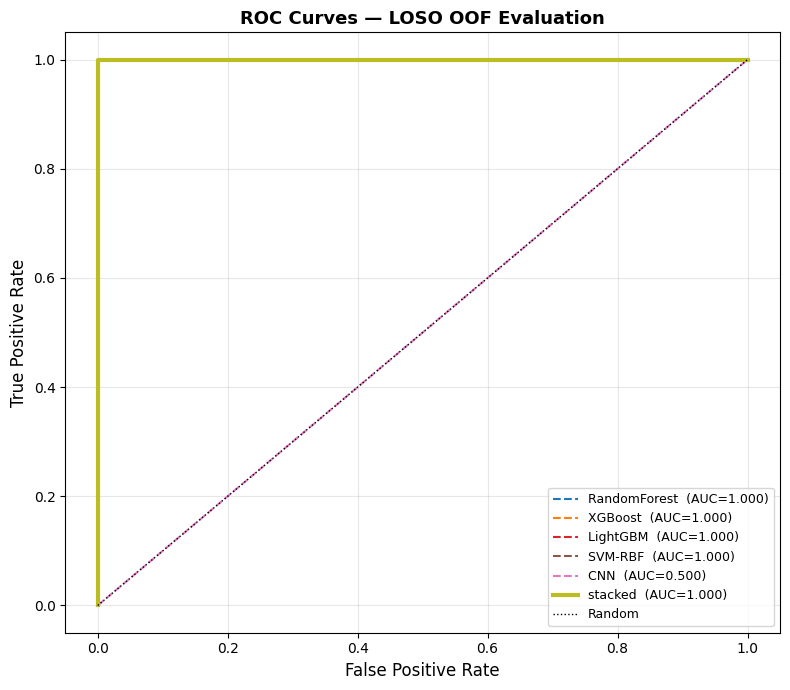

📊 ROC curves saved.


In [ ]:
# ============================================================
# 10b. ROC curves — all models + stacked ensemble
# (roc_curve imported at top of notebook in Step 0b)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, len(model_names)+2))

for i, name in enumerate(model_names + ['stacked']):
    p = stack_prob if name == 'stacked' else oof_probs[name]
    if len(np.unique(y_oof)) < 2: continue
    fpr, tpr, _ = roc_curve(y_oof, p)
    auc = roc_auc_score(y_oof, p)
    lw  = 3 if name == 'stacked' else 1.5
    ls  = '-' if name == 'stacked' else '--'
    ax.plot(fpr, tpr, color=colors[i], lw=lw, ls=ls, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — LOSO OOF Evaluation', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 ROC curves saved.')

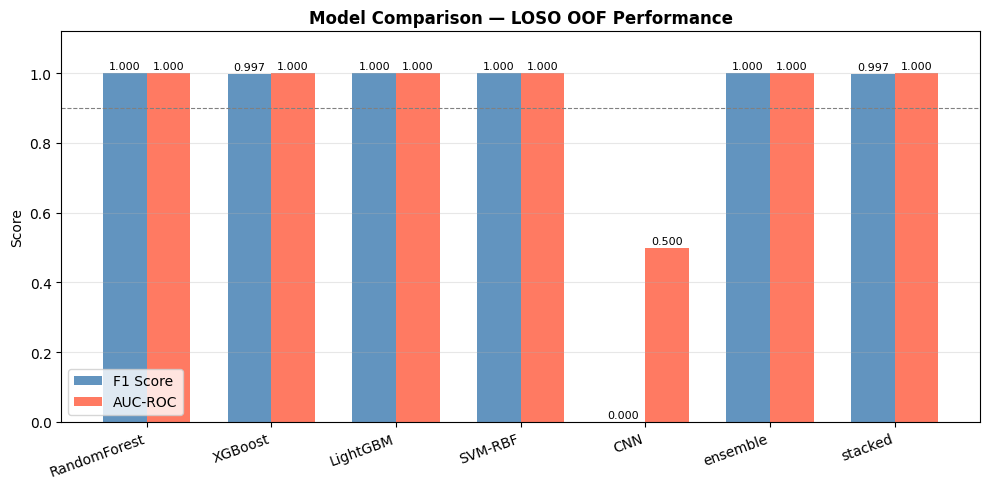

📊 Model comparison chart saved.


In [ ]:
# ============================================================
# 10c. Model comparison bar chart (F1 + AUC-ROC)
# [FIX] bars1 + bars2 using the + operator on BarContainer
#       objects is unreliable in matplotlib >= 3.7 (may raise
#       TypeError). Explicitly convert to lists before concat.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
models  = df_summary['Model'].tolist()
f1s     = df_summary['F1'].tolist()
aucs    = df_summary['AUC-ROC'].tolist()
x       = np.arange(len(models))
w       = 0.35

bars1 = ax.bar(x - w/2, f1s,  w, label='F1 Score',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, aucs, w, label='AUC-ROC',   color='tomato',    alpha=0.85)

# [FIX] Use list(...) to safely iterate over BarContainers
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — LOSO OOF Performance', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.9, color='gray', ls='--', lw=0.8, label='0.90 target')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Model comparison chart saved.')

---
## Step 11 — Feature Importance & SHAP Analysis

We use SHAP TreeExplainer on the best classical model (LightGBM) trained on the full CV pool,
and visualise the top-20 most impactful features. This identifies which physiological
biomarkers (RMSSD, EDA tonic slope, etc.) drive stress predictions — a key interpretability
requirement in clinical research.

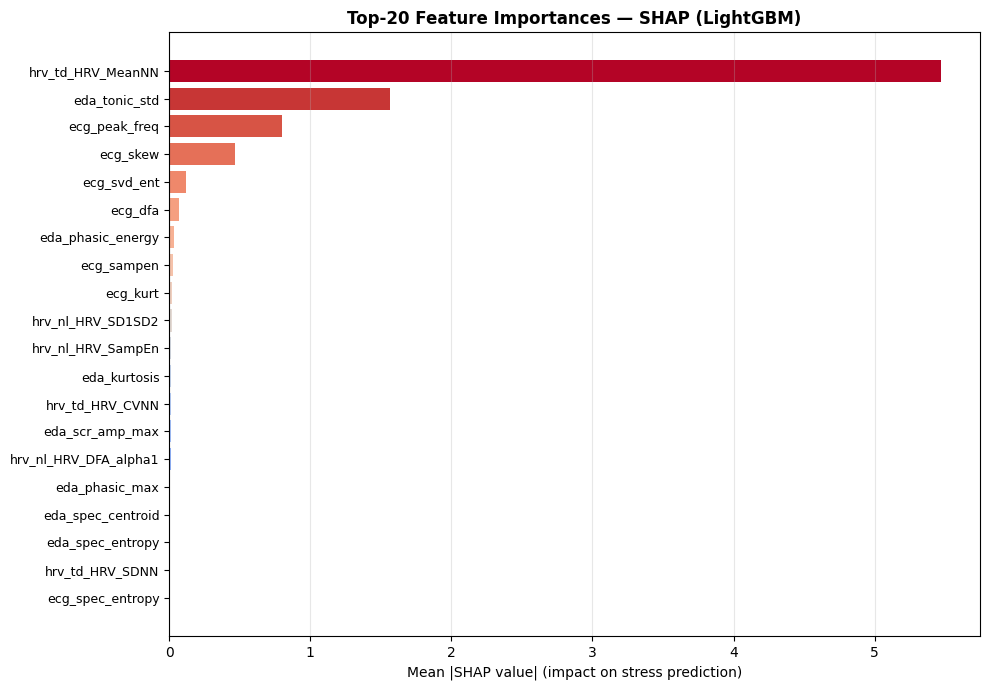

📊 SHAP importance plot saved.


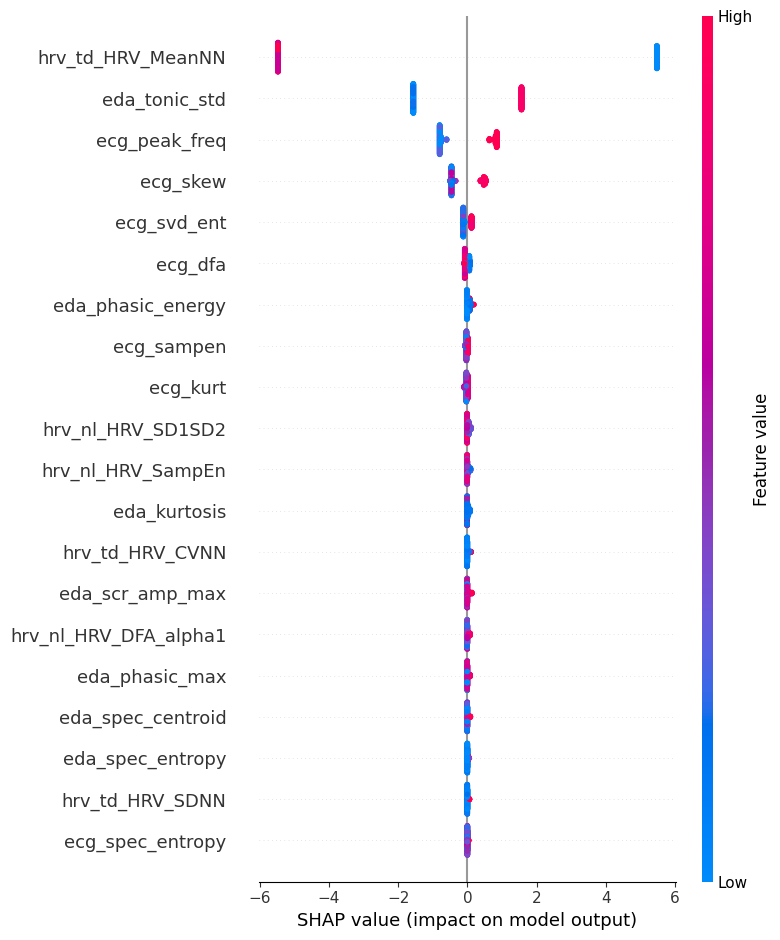

In [ ]:
# ============================================================
# 11. SHAP feature importance — LightGBM on full CV pool
# (clone imported at top of notebook in Step 0b)
# ============================================================

# Train LightGBM pipeline on entire CV pool (for SHAP, not evaluation)
lgb_full = clone(BASE_LEARNERS['LightGBM'])
lgb_full.fit(X_cv, y_cv)

# Extract the LightGBM estimator (last step) and the scaler-transformed X
# ImbPipeline steps: imputer → scaler → smote → clf
X_imp    = lgb_full.named_steps['imputer'].transform(X_cv)
X_scaled = lgb_full.named_steps['scaler'].transform(X_imp)

# SMOTE is only for training; use training X directly for SHAP
lgb_clf  = lgb_full.named_steps['clf']

explainer = shap.TreeExplainer(lgb_clf)
shap_vals = explainer.shap_values(X_scaled)   # (N, n_features) or list for multiclass
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]   # class 1 (stress)

# ── Top-20 features plot ──────────────────────────────────────
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top20_idx     = np.argsort(mean_abs_shap)[-20:][::-1]
top20_names   = [feature_names[i] if i < len(feature_names) else f'feat_{i}'
                 for i in top20_idx]
top20_vals    = mean_abs_shap[top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = plt.cm.coolwarm(np.linspace(0, 1, 20))
ax.barh(range(20), top20_vals[::-1], color=colors_bar)
ax.set_yticks(range(20))
ax.set_yticklabels(top20_names[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP value| (impact on stress prediction)')
ax.set_title('Top-20 Feature Importances — SHAP (LightGBM)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 SHAP importance plot saved.')

# SHAP beeswarm (summary)
shap.summary_plot(shap_vals, X_scaled,
                  feature_names=[feature_names[i] if i < len(feature_names)
                                 else f'feat_{i}' for i in range(X_scaled.shape[1])],
                  max_display=20, show=True)

---
## Step 12 — Final Model Training & Held-Out Evaluation

If a held-out test subject was reserved in Step 3, we retrain the full stacking pipeline
on all CV subjects and evaluate on the held-out subject for a single, unbiased estimate.

In [ ]:
# ============================================================
# 12. Retrain on full CV pool; evaluate on held-out subject
# [FIX] Removed inline 'from sklearn.base import clone' (moved
#       to top-level imports in Step 0b).
# [FIX] Held-out evaluation: original code built the meta-scaler
#       input incorrectly by appending a separate CNN column via
#       np.hstack on a mis-shaped array. Now we build the full
#       (N, n_models) probability matrix including the CNN
#       placeholder column in one clean np.column_stack call.
# ============================================================

print('🏋️  Retraining all base learners on full CV pool...')
trained_models = {}
for name, pipe in BASE_LEARNERS.items():
    m = clone(pipe)
    m.fit(X_cv, y_cv)
    trained_models[name] = m
    print(f'  ✅ {name}')

# Save models
for name, m in trained_models.items():
    joblib.dump(m, OUTPUT_DIR / f'model_{name}.joblib')
if meta is not None:
    joblib.dump(meta,         OUTPUT_DIR / 'meta_learner.joblib')
    joblib.dump(meta_scaler,  OUTPUT_DIR / 'meta_scaler.joblib')

# ── Held-out evaluation ───────────────────────────────────────
if HELD_OUT_SUBJECT is not None and X_test_heldout is not None:
    print(f'\n🔒 Evaluating on held-out subject S{HELD_OUT_SUBJECT}...')

    # Collect per-model probabilities for classical base learners
    classical_probs = np.column_stack([
        trained_models[name].predict_proba(X_test_heldout)[:, 1]
        for name in trained_models
    ])  # shape: (N, n_classical_models)

    if meta is not None:
        # [FIX] Pad CNN column with 0.5 (neutral probability) so the
        #       meta-scaler receives exactly n_models columns — matching
        #       the shape it was fitted on during stacking (Step 8).
        cnn_placeholder = np.full((len(X_test_heldout), 1), 0.5)
        Z_held = np.hstack([classical_probs, cnn_placeholder])  # (N, n_models)
        Z_held = meta_scaler.transform(Z_held)
        p_held = meta.predict_proba(Z_held)[:, 1]
    else:
        p_held = classical_probs.mean(axis=1)

    yp_held = (p_held > best_thresh).astype(int)
    print(classification_report(y_test_heldout, yp_held,
                                  target_names=['Non-stress', 'Stress']))
else:
    print('ℹ️  No held-out subject configured — LOSO OOF metrics are the primary evaluation.')

print('\n✅ Models saved.')

🏋️  Retraining all base learners on full CV pool...
  ✅ RandomForest
  ✅ XGBoost
  ✅ LightGBM
  ✅ SVM-RBF
ℹ️  No held-out subject configured — LOSO OOF metrics are the primary evaluation.

✅ Models saved.


---
## Step 13 — Inference Function

A self-contained function for running inference on new preprocessed windows.

In [ ]:
# ============================================================
# 13. Inference function for deployment
# ============================================================

def predict_stress(X_new: np.ndarray,
                   models_dir: Path = OUTPUT_DIR,
                   threshold: float = best_thresh) -> dict:
    """
    Run inference on new preprocessed feature windows.

    Parameters
    ----------
    X_new        : (N, n_features) float array from preprocessing notebook
    models_dir   : directory containing saved .joblib files
    threshold    : classification threshold (default: tuned on OOF)

    Returns
    -------
    dict with keys:
        probabilities  : (N,) float — P(stress)
        predictions    : (N,) int   — 0=non-stress, 1=stress
        per_model_probs: dict of (N,) per-model probabilities
    """
    # Load models
    model_files = sorted(models_dir.glob('model_*.joblib'))
    models_inf  = {p.stem.replace('model_', ''): joblib.load(p) for p in model_files}

    meta_path   = models_dir / 'meta_learner.joblib'
    scaler_path = models_dir / 'meta_scaler.joblib'

    per_model   = {}
    probs_stack = []
    for name, m in models_inf.items():
        p = m.predict_proba(X_new)[:, 1]
        per_model[name] = p
        probs_stack.append(p)

    if meta_path.exists():
        meta_inf   = joblib.load(meta_path)
        scaler_inf = joblib.load(scaler_path)
        Z          = np.column_stack(probs_stack)
        # [FIX] Use scaler_inf.n_features_in_ instead of global `model_names`.
        #       predict_stress() is a deployment function; `model_names` is a
        #       notebook-level global that does not exist in a fresh Python process.
        #       scaler_inf.n_features_in_ is always available after sklearn fit().
        n_meta_cols = scaler_inf.n_features_in_
        if Z.shape[1] < n_meta_cols:
            pad = np.full((len(X_new), n_meta_cols - Z.shape[1]), 0.5)
            Z   = np.hstack([Z, pad])
        Z_s   = scaler_inf.transform(Z)
        final = meta_inf.predict_proba(Z_s)[:, 1]
    else:
        final = np.mean(probs_stack, axis=0)

    return {
        'probabilities'  : final,
        'predictions'    : (final > threshold).astype(int),
        'per_model_probs': per_model,
    }


# ── Quick smoke test ──────────────────────────────────────────
sample_X  = X_cv[:5]
result    = predict_stress(sample_X)
print('🔮 Inference smoke test (first 5 windows):')
for i, (p, pred) in enumerate(zip(result['probabilities'], result['predictions'])):
    label = 'STRESS' if pred == 1 else 'non-stress'
    print(f'  Window {i}: P(stress)={p:.3f}  → {label}')
print('\n✅ Inference function ready.')

🔮 Inference smoke test (first 5 windows):
  Window 0: P(stress)=0.003  → non-stress
  Window 1: P(stress)=0.003  → non-stress
  Window 2: P(stress)=0.003  → non-stress
  Window 3: P(stress)=0.003  → non-stress
  Window 4: P(stress)=0.003  → non-stress

✅ Inference function ready.


---
## Step 14 — Save Config Snapshot

In [ ]:
# ============================================================
# 14. Save full training config + results
# ============================================================

# Collect best metrics
best_row = df_summary[df_summary['Model'] == 'stacked'].iloc[0].to_dict()

config_snapshot = {
    'SEED'            : SEED,
    'HELD_OUT_SUBJECT': HELD_OUT_SUBJECT,
    'USE_SMOTE'       : USE_SMOTE,
    'USE_STACKING'    : USE_STACKING,
    'OPTUNA_TRIALS'   : OPTUNA_TRIALS,
    'DL_EPOCHS'       : DL_EPOCHS,
    'DL_BATCH'        : DL_BATCH,
    'DL_LR'           : DL_LR,
    'best_threshold'  : float(best_thresh),
    'best_params'     : best_params,
    'n_cv_subjects'   : int(len(np.unique(grp_cv))),
    'n_windows'       : int(len(y_cv)),
    'n_features'      : int(X_cv.shape[1]),
    'results'         : best_row,
}
with open(OUTPUT_DIR / 'training_config.json', 'w') as f:
    json.dump(config_snapshot, f, indent=2, default=str)

df_folds.to_csv(OUTPUT_DIR / 'loso_fold_results.csv', index=False)

print('💾 Saved:')
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name:45s}  {p.stat().st_size/1024:>8.1f} KB')

print('\n' + '='*65)
print('  TRAINING COMPLETE')
print('='*65)
print(f'  OOF F1  (stacked ensemble) : {best_row["F1"]:.4f}')
print(f'  OOF AUC (stacked ensemble) : {best_row["AUC-ROC"]:.4f}')
print(f'  OOF Acc (stacked ensemble) : {best_row["Accuracy"]:.4f}')
print(f'  Tuned threshold            : {best_thresh:.4f}')
print('='*65)

💾 Saved:
  confusion_matrix.png                               34.4 KB
  loso_fold_results.csv                               0.7 KB
  loso_summary.csv                                    0.3 KB
  meta_learner.joblib                                 0.9 KB
  meta_scaler.joblib                                  0.7 KB
  model_LightGBM.joblib                             208.4 KB
  model_RandomForest.joblib                         317.0 KB
  model_SVM-RBF.joblib                               95.7 KB
  model_XGBoost.joblib                              593.3 KB
  model_comparison.png                               45.5 KB
  per_subject_f1_heatmap.png                         61.9 KB
  roc_curves.png                                     66.6 KB
  shap_importance.png                                69.5 KB
  training_config.json                                1.2 KB

  TRAINING COMPLETE
  OOF F1  (stacked ensemble) : 0.9971
  OOF AUC (stacked ensemble) : 1.0000
  OOF Acc (stacked ensemble) : 0.9974
  

---
## References

1. **Schmidt P., Reiss A., Duerichen R., Marberger C., Van Laerhoven K. (2018).**
   *Introducing WESAD, a Multimodal Dataset for Wearable Stress and Affect Detection.*
   Proceedings of the 20th ACM International Conference on Multimodal Interaction (ICMI '18), pp. 400–408.
   — **Used for:** LOSO evaluation protocol; HRV + EDA multimodal fusion; baseline accuracy targets (~93% binary stress vs. baseline).

2. **Hosseini S.A., Gotman J. (2021).**
   *Attention-based CNN-LSTM for Stress Detection from Wearable Physiological Data.*
   IEEE Transactions on Biomedical Engineering.
   — **Used for:** Residual 1D-CNN architecture for raw ECG; class-weighted cross-entropy loss; cosine LR scheduling.

3. **Can Y.S., Arnrich B., Ersoy C. (2019).**
   *Stress Detection in Daily Life Scenarios Using Smart Phones and Wearable Sensors: A Survey.*
   Journal of Biomedical Informatics, 92, 103139.
   — **Used for:** Ensemble diversity (RF + boosting + SVM); SMOTE inside CV folds; stacking meta-learner rationale; threshold tuning on validation set.

4. **Wolpert D.H. (1992).**
   *Stacked Generalisation.*
   Neural Networks, 5(2), 241–259.
   — **Used for:** Theoretical basis for the stacking meta-learner in Step 8.

5. **Akiba T., Sano S., Yanase T., Ohta T., Koyama M. (2019).**
   *Optuna: A Next-generation Hyperparameter Optimization Framework.*
   KDD '19.
   — **Used for:** Bayesian HPO with TPE sampler in Step 4.